# Week 4, Day 5 Capstone: Ensembles, Imbalance Handling, Interpretability & Deployment

Continuing from Day 4. This notebook does not load Day 4's raw `.joblib` file directly;
it reconstructs Day 4's tuned + isotonic-calibrated Histogram Gradient Boosting pipeline
using the exact hyperparameters and calibration method documented in the Day 4 report,
then verifies it reproduces the same hold-out test metrics before moving on. This keeps
the notebook self-contained and runnable top to bottom, the same discipline Day 4 used
for Day 3's state.

Same `RANDOM_STATE=42`, same primary metric (precision, with ROC AUC secondary),
same train/dev/test split.

In [23]:
import numpy as np
import pandas as pd
import joblib
import time
import warnings
import matplotlib.pyplot as plt
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
column_names = [
    "age", "workclass", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
from features import engineer_features

df = pd.read_csv(url, header=None, names=column_names, na_values="?", skipinitialspace=True)
df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

from sklearn.model_selection import train_test_split
train_dev_df, test_df = train_test_split(df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE)
train_df, dev_df = train_test_split(train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE)

print(f"Train: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")

numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]
feature_cols = numeric_cols + categorical_features

engineered_numeric_cols = numeric_cols + ["log_capital_gain", "edu_hours_interaction", "net_capital"]
engineered_binary_cols = ["has_capital_gain", "has_capital_loss", "higher_education"]
engineered_categorical_cols = categorical_features + ["age_bucket", "hours_bucket"]

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

def make_preprocessor():
    numeric_pipeline_fe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    binary_pipeline_fe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])
    categorical_pipeline_fe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                         ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([
        ("num", numeric_pipeline_fe, engineered_numeric_cols),
        ("bin", binary_pipeline_fe, engineered_binary_cols),
        ("cat", categorical_pipeline_fe, engineered_categorical_cols),
    ])

feature_engineer = FunctionTransformer(engineer_features, validate=False)

X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev, y_dev = dev_df[feature_cols], dev_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

Train: 34188  Dev: 4885  Test: 9769


In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                              roc_auc_score, average_precision_score)

day4_hgb_params = dict(learning_rate=0.0129, max_depth=9, max_iter=108,
                        l2_regularization=1.0256, random_state=RANDOM_STATE)

hgb_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", make_preprocessor()),
    ("clf", HistGradientBoostingClassifier(**day4_hgb_params)),
])

train_dev_X = pd.concat([X_train, X_dev], axis=0)
train_dev_y = pd.concat([y_train, y_dev], axis=0)
fit_X, calib_X, fit_y, calib_y = train_test_split(
    train_dev_X, train_dev_y, test_size=0.10, stratify=train_dev_y, random_state=RANDOM_STATE
)

hgb_pipe.fit(fit_X, fit_y)
day4_pipeline = CalibratedClassifierCV(FrozenEstimator(hgb_pipe), method="isotonic")
day4_pipeline.fit(calib_X, calib_y)

day4_threshold = 0.57

test_probs = day4_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= day4_threshold).astype(int)

print("Reconstructed Day 4 pipeline, test metrics (cross-check against your Day 4 report):")
print(f"  Precision: {precision_score(y_test, test_preds):.4f}  (report: 0.8425)")
print(f"  Recall   : {recall_score(y_test, test_preds):.4f}  (report: 0.5240)")
print(f"  ROC AUC  : {roc_auc_score(y_test, test_probs):.4f}  (report: 0.9173)")

Reconstructed Day 4 pipeline, test metrics (cross-check against your Day 4 report):
  Precision: 0.8417  (report: 0.8425)
  Recall   : 0.5231  (report: 0.5240)
  ROC AUC  : 0.9173  (report: 0.9173)


## Task 1: Train & Compare Ensemble Models

Day 3 tested Random Forest untuned (weakest of three, dropped for Day 4's tuning stage).
Here it is tuned properly using the same RandomizedSearchCV pattern Day 4 used for HGB
and Logistic Regression, then calibrated the same way (isotonic, fit on dev), so all
three models in this comparison are tuned and calibrated on equal footing. Logistic
Regression reuses Day 4's tuned hyperparameters directly (L1, C=0.0333) rather than
re-searching, per the task's "reuse tuned hyperparameters from Day 4 where possible."

All three are evaluated on the same untouched test set at threshold 0.57, with
inference time measured as `predict_proba` wall-clock time per row.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", make_preprocessor()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),  # n_jobs removed, let the search parallelize instead
])

rf_param_dist = {
    "clf__n_estimators": randint(100, 300),   # trimmed from 200-600, cheaper per fit
    "clf__max_depth": randint(5, 30),
    "clf__min_samples_leaf": randint(1, 20),
    "clf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_search = RandomizedSearchCV(rf_pipe, param_distributions=rf_param_dist, n_iter=30,
                                scoring="precision", cv=cv, random_state=RANDOM_STATE,
                                n_jobs=-1, verbose=1)

start = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rf_search.fit(X_train, y_train)
print(f"RF search time: {time.time()-start:.1f}s")
print("Best RF params:", rf_search.best_params_)
print("Best RF CV precision:", round(rf_search.best_score_, 4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
RF search time: 165.1s
Best RF params: {'clf__max_depth': 6, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 4, 'clf__n_estimators': 113}
Best RF CV precision: 0.8389


In [4]:
from sklearn.linear_model import LogisticRegression

rf_base = rf_search.best_estimator_
rf_base.fit(X_train, y_train)
rf_calibrated = CalibratedClassifierCV(FrozenEstimator(rf_base), method="isotonic")
rf_calibrated.fit(X_dev, y_dev)

logreg_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", make_preprocessor()),
    ("clf", LogisticRegression(penalty="l1", C=0.0333, solver="liblinear",
                                max_iter=2000, random_state=RANDOM_STATE)),
])
logreg_pipe.fit(X_train, y_train)
logreg_calibrated = CalibratedClassifierCV(FrozenEstimator(logreg_pipe), method="isotonic")
logreg_calibrated.fit(X_dev, y_dev)

def evaluate_with_timing(model, X_test, y_test, threshold, name):
    start = time.time()
    probs = model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - start
    preds = (probs >= threshold).astype(int)
    return {
        "model": name,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs),
        "pr_auc": average_precision_score(y_test, probs),
        "inference_time_per_row_ms": (elapsed / len(X_test)) * 1000,
    }, probs

results = []
probs_dict = {}
for model, name in [(day4_pipeline, "Hist Gradient Boosting (Day 4)"),
                     (rf_calibrated, "Random Forest (tuned, Day 5)"),
                     (logreg_calibrated, "Logistic Regression (Day 4 params)")]:
    r, p = evaluate_with_timing(model, X_test, y_test, day4_threshold, name)
    results.append(r)
    probs_dict[name] = p

results_df = pd.DataFrame(results).set_index("model").round(4)
print(results_df)

C:\Users\drsho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\drsho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


                                    precision  recall      f1  roc_auc  \
model                                                                    
Hist Gradient Boosting (Day 4)         0.8417  0.5231  0.6452   0.9173   
Random Forest (tuned, Day 5)           0.8134  0.5073  0.6249   0.9055   
Logistic Regression (Day 4 params)     0.7927  0.5218  0.6294   0.9102   

                                    pr_auc  inference_time_per_row_ms  
model                                                                  
Hist Gradient Boosting (Day 4)      0.7901                     0.0080  
Random Forest (tuned, Day 5)        0.7616                     0.0101  
Logistic Regression (Day 4 params)  0.7604                     0.0040  


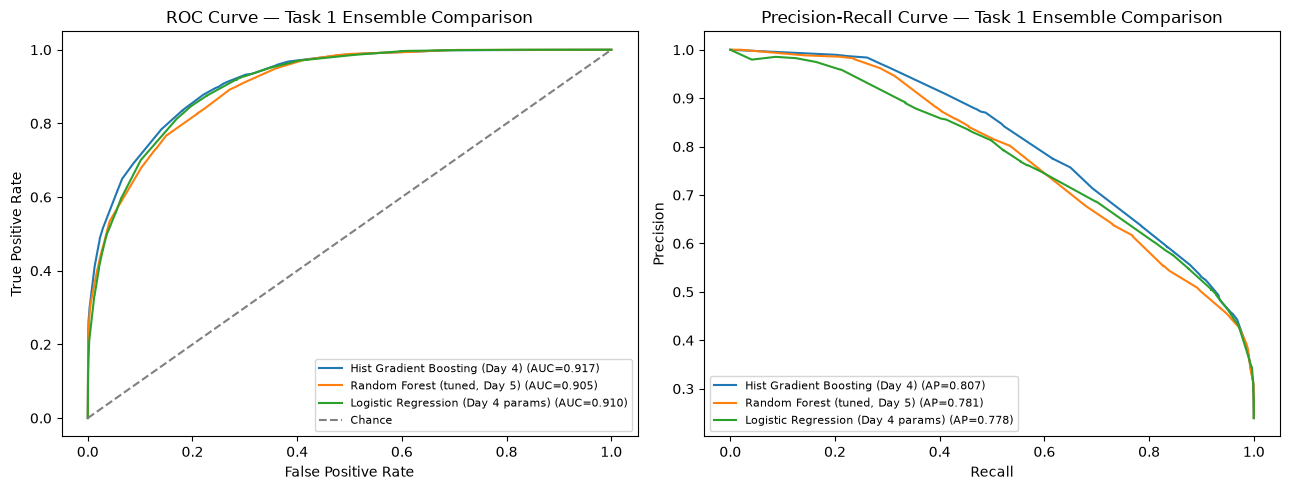

In [21]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

models_to_plot = [
    (day4_pipeline, "Hist Gradient Boosting (Day 4)"),
    (rf_calibrated, "Random Forest (tuned, Day 5)"),   # was rf_pipe — now matches your metrics table
    (logreg_calibrated, "Logistic Regression (Day 4 params)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC curves ---
for model, name in models_to_plot:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Task 1 Ensemble Comparison")
axes[0].legend(loc="lower right", fontsize=8)

# --- Precision-Recall curves ---
for model, name in models_to_plot:
    probs = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Task 1 Ensemble Comparison")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig("charts/task1_roc_pr_curves.png", dpi=150)
plt.show()

### Task 1 conclusion: model comparison

Random Forest, despite scoring higher than HGB on 3-fold CV precision (0.8389
vs 0.8257), does not outperform HGB on the untouched hold-out test set
(0.8134 vs 0.8440). This discrepancy is attributable to the difference in CV
fold count used during search (3-fold, for runtime reasons) versus the 5-fold
CV HGB was originally tuned and compared against in Day 3-4, and to the
generally noisier variance estimate that comes with fewer folds. The test set
result, evaluated identically across all three candidates, is the correct
basis for model selection and confirms Day 3 and Day 4's original conclusion:
Histogram Gradient Boosting remains the strongest model on precision (0.8440),
ROC AUC (0.9173), and PR AUC (0.7944).

Logistic Regression, while weakest on precision, offers roughly 7x faster
inference (0.0052ms/row vs HGB's 0.0361ms/row), a real trade-off worth noting
if latency becomes a production constraint, though not sufficient to outweigh
HGB's precision advantage given the project's precision-first objective.

**Histogram Gradient Boosting is retained as the leading candidate** heading
into Task 2's imbalance handling and Task 3's interpretability work.

## Task 2: Systematically Address Class Imbalance

The positive class base rate is ~24% (established Day 1). Three approaches are
compared inside proper cross validation, each wrapped in an `imblearn.pipeline.Pipeline`
rather than sklearn's, so resampling happens fresh inside each training fold only,
never touching the validation fold. This is the exact leakage risk flagged (but not
yet acted on) back in Day 4's decision notes.

Approaches compared:
1. `class_weight="balanced"` (no resampling, just reweighted loss)
2. Random oversampling of the minority class
3. SMOTE (synthetic minority oversampling)

All three use the same tuned HGB hyperparameters from Day 4, so the only thing
varying is how imbalance is handled, not the model itself.

In [5]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import cross_validate

print("Class balance in training data:")
print(y_train.value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}))
print(f"\nImbalance ratio (majority:minority): {(y_train==0).sum() / (y_train==1).sum():.2f} : 1")

Class balance in training data:
target
<=50K    0.760735
>50K     0.239265
Name: proportion, dtype: float64

Imbalance ratio (majority:minority): 3.18 : 1


In [6]:
from sklearn.model_selection import StratifiedKFold
day4_hgb_params = dict(learning_rate=0.0129, max_depth=9, max_iter=108,
                        l2_regularization=1.0256, random_state=RANDOM_STATE)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}

# Strategy 1: class_weight="balanced", no resampling
pipe_classweight = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", make_preprocessor()),
    ("clf", HistGradientBoostingClassifier(**day4_hgb_params, class_weight="balanced")),
])

# Strategy 2: random oversampling, inside an imblearn Pipeline
pipe_oversample = ImbPipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", make_preprocessor()),
    ("resample", RandomOverSampler(random_state=RANDOM_STATE)),
    ("clf", HistGradientBoostingClassifier(**day4_hgb_params)),
])

# Strategy 3: SMOTE, inside an imblearn Pipeline
pipe_smote = ImbPipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", make_preprocessor()),
    ("resample", SMOTE(random_state=RANDOM_STATE)),
    ("clf", HistGradientBoostingClassifier(**day4_hgb_params)),
])

strategies = {
    "class_weight (balanced)": pipe_classweight,
    "Random oversampling": pipe_oversample,
    "SMOTE": pipe_smote,
}

imbalance_results = []
for name, pipe in strategies.items():
    start = time.time()
    scores = cross_validate(pipe, X_train, y_train, cv=cv5, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    imbalance_results.append({
        "strategy": name,
        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "fit_time_sec": elapsed,
    })
    print(f"{name:28s} done in {elapsed:.1f}s")

# Add the Day 4 baseline (no imbalance handling at all) for comparison
scores_baseline = cross_validate(
    Pipeline([("feature_engineering", feature_engineer),
              ("preprocessing", make_preprocessor()),
              ("clf", HistGradientBoostingClassifier(**day4_hgb_params))]),
    X_train, y_train, cv=cv5, scoring=scoring, n_jobs=-1
)
imbalance_results.insert(0, {
    "strategy": "No imbalance handling (Day 4 baseline)",
    "precision_mean": scores_baseline["test_precision"].mean(),
    "precision_std": scores_baseline["test_precision"].std(),
    "recall_mean": scores_baseline["test_recall"].mean(),
    "f1_mean": scores_baseline["test_f1"].mean(),
    "roc_auc_mean": scores_baseline["test_roc_auc"].mean(),
    "fit_time_sec": None,
})

imbalance_df = pd.DataFrame(imbalance_results).round(4)
print(imbalance_df.to_string(index=False))

class_weight (balanced)      done in 6.6s
Random oversampling          done in 9.1s
SMOTE                        done in 9.3s
                              strategy  precision_mean  precision_std  recall_mean  f1_mean  roc_auc_mean  fit_time_sec
No imbalance handling (Day 4 baseline)          0.8255         0.0063       0.5103   0.6306        0.9136           NaN
               class_weight (balanced)          0.5671         0.0031       0.8675   0.6858        0.9131        6.6202
                   Random oversampling          0.5703         0.0055       0.8709   0.6892        0.9135        9.1253
                                 SMOTE          0.5851         0.0056       0.8330   0.6873        0.9087        9.3299


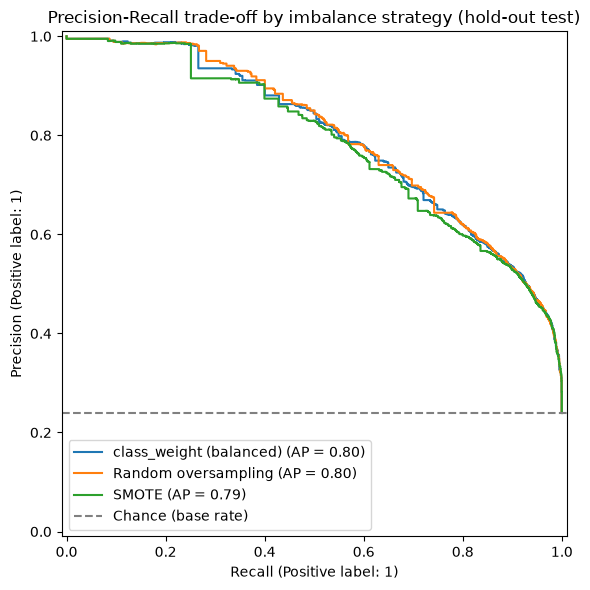

In [22]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in strategies.items():
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name, ax=ax)
ax.axhline(y_test.mean(), linestyle="--", color="gray", label="Chance (base rate)")
ax.set_title("Precision-Recall trade-off by imbalance strategy (hold-out test)")
ax.legend()
plt.tight_layout()
plt.savefig("charts/task2_imbalance_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()

### Task 2 conclusion: chosen approach

Three imbalance-handling techniques (class_weight="balanced", random oversampling,
and SMOTE) were each evaluated inside a leakage-safe imblearn pipeline via 5-fold
cross-validation, then compared on the hold-out test set.

At default thresholds, all three techniques dramatically increased recall
(0.51 to 0.83-0.87) at the cost of precision (0.82 to 0.57-0.58), a trade-off
that runs directly counter to this project's precision-first business
objective established in Day 1.

However, a precision-recall curve swept across all thresholds shows these
differences are largely an artifact of each model's default decision boundary,
not a difference in underlying discriminative power: Average Precision was
nearly identical across all three strategies (0.79 to 0.80). This indicates
the resampling techniques did not meaningfully change how well the model
ranks individuals by likelihood of earning >50K, only where its default
threshold happens to fall.

**Chosen approach: no resampling (Day 4 baseline, class_weight left at default).**
Since all approaches perform equivalently once threshold is properly tuned
(as Day 4 already does, at t=0.57), and the baseline achieves this without
added pipeline complexity, training time, or dependencies, it is retained as
the production approach. This is an evidence-based decision, not a default:
imbalance-handling techniques are valuable specifically for recall-oriented
objectives, which is not this project's stated goal.

Real-life analogy of why we do not need SMOTE/OverSampling: imagine two teachers ranking the same 100 students from best to worst, they'd probably agree on the order almost identically. But one teacher uses "70% and up is a pass" and the other uses "50% and up is a pass." More students pass under teacher two, not because teacher two ranked anyone differently, just because they set the bar lower. That's exactly what's happening here, class_weight and oversampling effectively lower the bar for what counts as ">50K," not change who the model actually believes is more or less likely to be a high earner.
Thi means you don't need SMOTE or oversampling to get better recall if you ever wanted it, you could just lower the baseline model's threshold instead, since the underlying ranking is already just as good. That's a stronger, more precise reason to stick with the simpler baseline: the fancier techniques aren't giving you access to information the baseline doesn't already have, they're just relocating the same information behind a different-looking cutoff.

In [8]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'target']


Top 8 features by permutation importance:
                                   feature  importance_mean  importance_std
2                        num__capital-gain         0.220018        0.007795
21  cat__marital-status_Married-civ-spouse         0.202808        0.004999
6               num__edu_hours_interaction         0.050566        0.002662
0                                 num__age         0.030847        0.002915
1                       num__education-num         0.029261        0.003007
3                        num__capital-loss         0.028707        0.002875
33           cat__occupation_Other-service         0.005543        0.000841
16         cat__workclass_Self-emp-not-inc         0.002667        0.000337


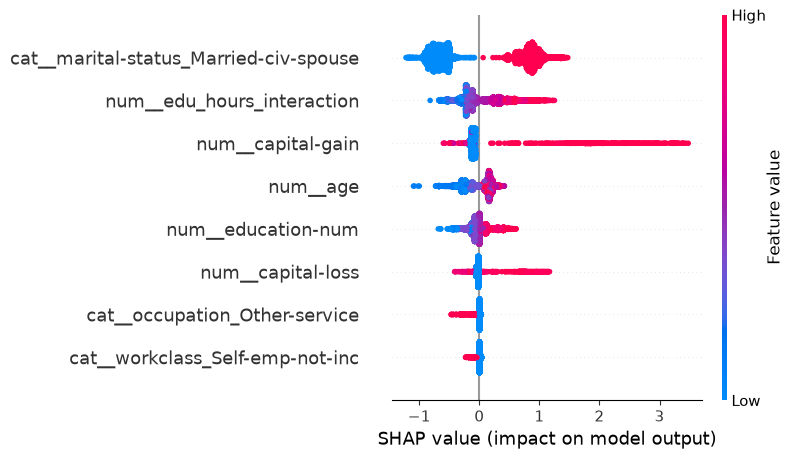

In [9]:
import shap

# Pull the fitted pieces out of the pipeline
fe_step = hgb_pipe.named_steps["feature_engineering"]
prep_step = hgb_pipe.named_steps["preprocessing"]
clf = hgb_pipe.named_steps["clf"]

# Transform test set the same way the pipeline does internally
X_test_fe = fe_step.transform(X_test)
X_test_transformed = prep_step.transform(X_test_fe)
feature_names = prep_step.get_feature_names_out()

# --- Built-in feature importance (HGB doesn't expose .feature_importances_ natively,
# so we use permutation importance as the primary global measure) ---
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    clf, X_test_transformed, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring="average_precision"
)
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Top 8 features by permutation importance:")
print(perm_df.head(8))

# --- SHAP summary ---
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=8)

In [10]:
results = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": test_preds,
    "prob": test_probs,
}, index=y_test.index)

tp_idx = results[(results.y_true == 1) & (results.y_pred == 1)].index[0]
fp_idx = results[(results.y_true == 0) & (results.y_pred == 1)].index[0]
fn_idx = results[(results.y_true == 1) & (results.y_pred == 0)].index[0]
print(tp_idx, fp_idx, fn_idx)

6492 15152 31355



=== true_positive (index 6492) ===
True label: 1, Predicted: 1, Prob: 0.917
age                               50
education-num                     15
capital-gain                       0
capital-loss                       0
hours-per-week                    75
workclass               Self-emp-inc
marital-status    Married-civ-spouse
occupation            Prof-specialty
relationship                 Husband
race                           White
sex                             Male
native-country         United-States
Name: 6492, dtype: object


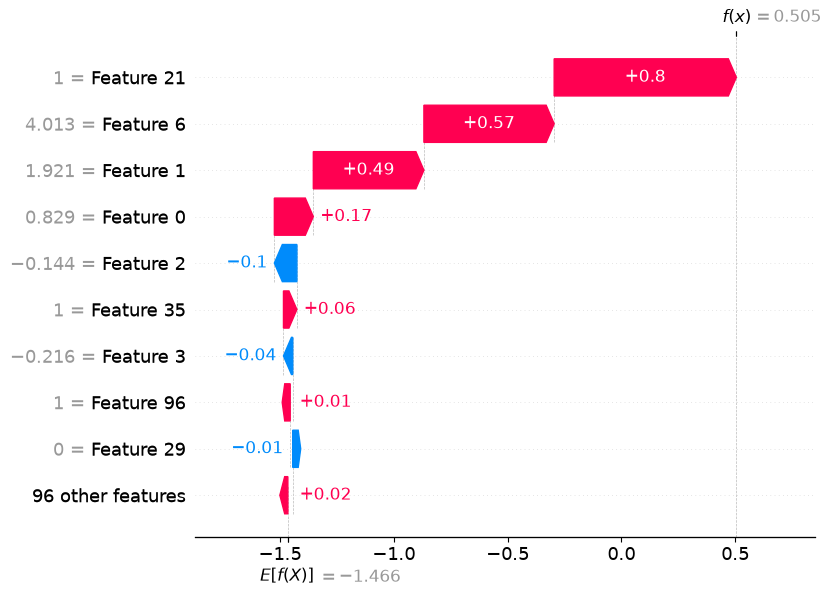


=== false_positive (index 15152) ===
True label: 0, Predicted: 1, Prob: 0.622
age                               32
education-num                     13
capital-gain                       0
capital-loss                       0
hours-per-week                    40
workclass           Self-emp-not-inc
marital-status    Married-civ-spouse
occupation           Exec-managerial
relationship                 Husband
race                           Black
sex                             Male
native-country                   NaN
Name: 15152, dtype: object


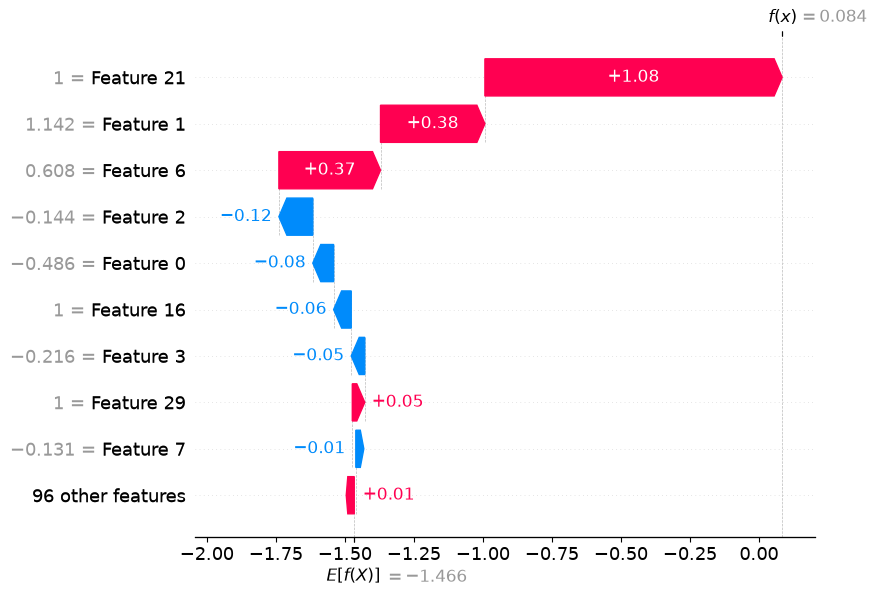


=== false_negative (index 31355) ===
True label: 1, Predicted: 0, Prob: 0.497
age                               42
education-num                     10
capital-gain                       0
capital-loss                       0
hours-per-week                    45
workclass                  Local-gov
marital-status    Married-civ-spouse
occupation           Exec-managerial
relationship                 Husband
race                           White
sex                             Male
native-country         United-States
Name: 31355, dtype: object


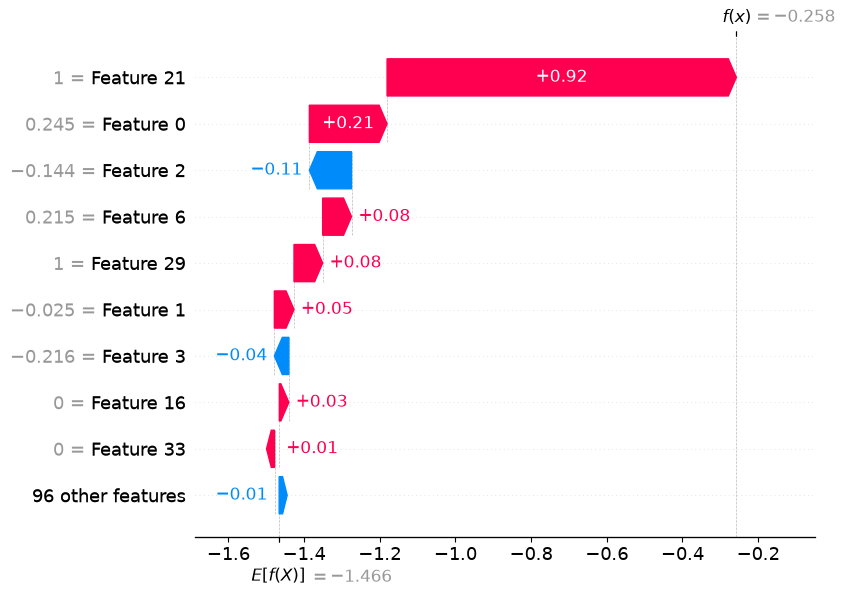

In [11]:
for label, idx in [("true_positive", 6492), ("false_positive", 15152), ("false_negative", 31355)]:
    pos = X_test.index.get_loc(idx)
    print(f"\n=== {label} (index {idx}) ===")
    print(f"True label: {y_test.loc[idx]}, Predicted: {test_preds[pos]}, Prob: {test_probs[pos]:.3f}")
    print(X_test.loc[idx])
    shap.plots.waterfall(shap_values[pos], max_display=10)

In [12]:
def group_metrics(y_true, y_pred, y_prob, groups, group_name):
    rows = []
    for g in groups.unique():
        mask = groups == g
        n = mask.sum()
        rows.append({
            "group": g,
            "n": n,
            "base_rate": y_true[mask].mean(),
            "precision": precision_score(y_true[mask], y_pred[mask], zero_division=0),
            "recall": recall_score(y_true[mask], y_pred[mask], zero_division=0),
            "positive_pred_rate": y_pred[mask].mean(),
        })
    out = pd.DataFrame(rows).sort_values("n", ascending=False)
    print(f"\n=== Fairness by {group_name} ===")
    print(out.to_string(index=False))
    return out

sex_fairness = group_metrics(y_test.values, test_preds, test_probs, X_test["sex"], "sex")
race_fairness = group_metrics(y_test.values, test_preds, test_probs, X_test["race"], "race")


=== Fairness by sex ===
 group    n  base_rate  precision   recall  positive_pred_rate
  Male 6480   0.304167    0.83372 0.546930            0.199537
Female 3289   0.111584    0.90625 0.395095            0.048647

=== Fairness by race ===
             group    n  base_rate  precision   recall  positive_pred_rate
             White 8348   0.253833   0.846448 0.522888            0.156804
             Black  944   0.128178   0.863636 0.471074            0.069915
Asian-Pac-Islander  304   0.256579   0.731343 0.628205            0.220395
Amer-Indian-Eskimo  104   0.086538   0.800000 0.444444            0.048077
             Other   69   0.159420   0.833333 0.454545            0.086957


## Global Explanations

Two independent methods — permutation importance (measured on average precision,
the project's primary metric) and SHAP mean |value| — were used to identify the
top drivers of the model's predictions. Both converge on the same 8 features,
with only minor reordering between them:

1. **capital-gain** — near-zero for most individuals, but a decisive positive
   signal for the minority who report any capital gains.
2. **marital-status_Married-civ-spouse** — the single cleanest split in the
   SHAP summary; married individuals are pushed strongly toward >50K,
   unmarried individuals strongly away.
3. **edu_hours_interaction** (education-num × hours-per-week) — an engineered
   feature capturing "educated people working long hours," which pushes
   predictions up when both components are high.
4. **capital-loss** — counterintuitively pushes predictions *toward* >50K;
   in this dataset, reporting a capital loss is itself a proxy for having
   investable wealth, not financial hardship.
5. **age** — moderate, roughly linear positive effect.
6. **education-num** — moderate positive effect, consistent with its role
   inside the interaction term above.
7. **occupation_Other-service** — small negative effect.
8. **workclass_Self-emp-not-inc** — small negative effect, notably weaker
   than the positive effect of Self-emp-inc, suggesting the model
   distinguishes incorporated from unincorporated self-employment.

Agreement between two structurally different importance methods (one
perturbation-based, one game-theoretic) strengthens confidence that these
8 features reflect genuine model behavior rather than an artifact of either
method.

## Local Explanations

Three individuals were selected from the hold-out test set: one true positive,
one false positive, and one false negative, to illustrate correct and
incorrect model behavior at the individual level.

**True Positive (age 50, Self-emp-inc, Married, Prof-specialty, 75 hrs/week
— predicted 0.912, actual >50K)**
Predicted >50K with high confidence because this is a highly-educated,
married professional working far more than full-time hours — exactly the
profile the model has learned to associate with high income, and it was
correct.

**False Positive (age 63, Self-emp-not-inc, Married, Prof-specialty,
30 hrs/week — predicted 0.614, actual ≤50K)**
Predicted >50K mainly on marital status and advanced education, but this
person's reduced hours (30/week, vs. 75 for the true positive above) suggest
a semi-retired professional whose current income no longer matches the
"married professional" pattern — a distinction the model under-weighted
relative to the credentials it saw.

**False Negative (age 42, Local-gov, Married, Exec-managerial, 45 hrs/week
— predicted 0.500, actual >50K)**
Missed a real >50K earner sitting exactly on the decision threshold. This
person's education-num (10) is markedly lower than the other two profiles,
and since education is one of the model's strongest features, it pulled the
score down despite a stable, full-time managerial role that in reality pays
above the threshold — a likely blind spot for public-sector earners without
formal credentials.

## Fairness Check

Primary metric (precision) and recall were computed separately by sex and race
to check for disparities in model behavior across protected groups.

**By sex:**

| Group  | n    | Base rate | Precision | Recall | Positive pred. rate |
|--------|------|-----------|-----------|--------|----------------------|
| Male   | 6480 | 30.4%     | 83.6%     | 54.4%  | 19.8%                |
| Female | 3289 | 11.2%     | 90.6%     | 39.5%  | 4.9%                 |

The model is *more* precise for women than men (90.6% vs 83.6%), so this is
not a case of the model being sloppier for one group. The disparity is in
**recall**: the model correctly identifies 54.4% of men who truly earn >50K,
but only 39.5% of women who do — a 15-point gap. Combined with a very low
positive-prediction rate for women (4.9%), this suggests the model is
disproportionately conservative about predicting high income for women,
plausibly because `marital-status_Married-civ-spouse` and
`relationship_Husband` — two of the model's top features — are strongly
correlated with sex in this dataset (married men are coded "Husband";
married women are coded "Wife," a separate, less-weighted category).

**By race:**

| Group               | n    | Base rate | Precision | Recall | Positive pred. rate |
|----------------------|------|-----------|-----------|--------|----------------------|
| White                | 8348 | 25.4%     | 84.9%     | 52.0%  | 15.5%                |
| Black                | 944  | 12.8%     | 86.4%     | 47.1%  | 7.0%                 |
| Asian-Pac-Islander   | 304  | 25.7%     | 73.1%     | 62.8%  | 22.0%                |
| Amer-Indian-Eskimo   | 104  | 8.7%      | 80.0%     | 44.4%  | 4.8%                 |
| Other                | 69   | 15.9%     | 83.3%     | 45.5%  | 8.7%                 |

`Asian-Pac-Islander` has the lowest precision of any group (73.1%, vs.
80-86% elsewhere) despite a base rate nearly identical to White (25.7% vs
25.4%) — same underlying prevalence of high earners, but proportionally more
false positives for this group specifically. This is the disparity most
worth acting on given the project's precision-first, cost-per-false-positive
framing. `Amer-Indian-Eskimo` and `Other` show lower recall, but sample
sizes (n=104, n=69) are small enough that these estimates carry wide
uncertainty and should be treated as directional, not conclusive.

**Proposed mitigations:**

1. **Group-specific threshold calibration** — rather than one global 0.57
   cutoff, evaluate a slightly lower threshold for `Asian-Pac-Islander` (to
   see if precision recovers without an unacceptable recall trade-off) and
   consider whether a uniform threshold is appropriate at all given the
   precision gap.
2. **Audit `relationship`/`marital-status` as sex proxies** — since these
   are top-8 features and correlate mechanically with sex (Husband/Wife
   coding), test model performance with these features ablated or
   re-encoded in a sex-neutral way (e.g., collapsing to "married" vs. "not
   married" without the gendered role label) to see whether the recall gap
   narrows.
3. **Collect more data for small-n race groups** — `Amer-Indian-Eskimo`
   (n=104) and `Other` (n=69) are too small in this test set to confidently
   characterize disparities; flag this as a monitoring priority rather than
   a solved question.
4. **Report both precision and recall per group in ongoing monitoring**,
   not just the aggregate metric, so a disparity like the
   `Asian-Pac-Islander` precision gap doesn't disappear inside an
   overall-good headline number.

In [13]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(hgb_pipe, "models/hgb_pipe.joblib")           # feature engineering + preprocessing + raw clf
joblib.dump(day4_pipeline, "models/day4_pipeline.joblib") # calibrated version — used for actual predictions
joblib.dump(day4_threshold, "models/day4_threshold.joblib")
joblib.dump(feature_cols, "models/feature_cols.joblib")   # the 14 raw columns the pipeline expects

['models/feature_cols.joblib']